## Preliminar

In [ ]:
import numpy as np


const = np.array([1.0])


def gauss(x: np.ndarray, mu: np.ndarray, sigma: float, A: float) -> np.ndarray:
    """
    x.shape = (N, d)
    mu.shape = (d,)

    Retorna un vector de forma (N,).
    """
    diff = x - mu
    norm2 = np.sum(diff**2, axis=1)
    return A * np.exp(-norm2 / (2 * sigma**2))


def constante_en_intervalo(
    x: np.ndarray,
    const: float,
    a: np.ndarray,
    b: np.ndarray,
) -> np.ndarray:
    """
    x.shape = (N,d)
    a.shape = (d,)
    b.shape = (d,)

    Retorna const sobre el hiperrrectángulo
    [a₁,b₁]×⋯×[a_d,b_d].
    """
    inside = np.all((a <= x) & (x <= b), axis=1)
    return const * inside


def funcion_constante(z: np.ndarray, const: float) -> np.ndarray:
    """
    z.shape = (N,d)
    """
    return np.full((z.shape[0],), const)


def kernel_gaussiano(x: np.ndarray, y: np.ndarray, sigma_K: float) -> np.ndarray:
    """
    x.shape = (N_consumer,d_x)
    y.shape = (N_resource,d_y)

    Retorna una matriz de forma
        (N_consumer,N_resource).
    """
    diff = x[:, None, :] - y[None, :, :]
    norm2 = np.sum(diff**2, axis=2)
    exp = np.exp(-norm2 / (2 * sigma_K**2))
    return exp / (sigma_K * np.sqrt(2 * np.pi))


def supply_rate_gaussiano(y: np.ndarray, sigma_in: float, M_in: float) -> np.ndarray:
    """
    y.shape = (N,d)
    """
    norm2 = np.sum(y**2, axis=1)
    exp = np.exp(-norm2 / (2 * sigma_in**2))
    return M_in * exp / (sigma_in * np.sqrt(2 * np.pi))

In [2]:
from src import Model

consumer_domain = np.array([[-2, 2], [-2, 2]])
resource_domain = np.array([[-2, 2], [-2, 2]])

## Estudio Mortalidad

#### Población muere

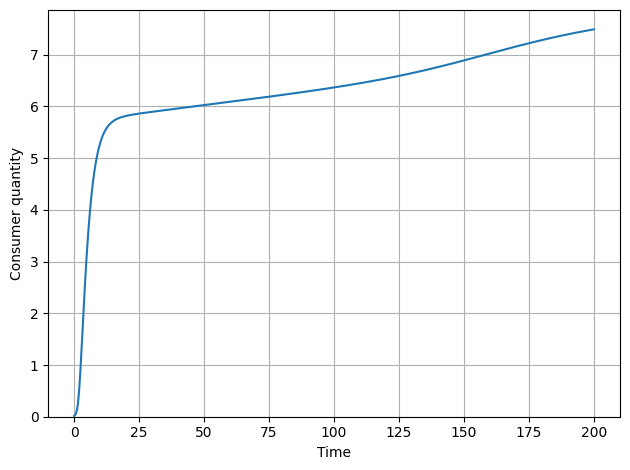

Frame: 0.
Frame: 0.
Frame: 100.
Frame: 200.
Frame: 300.
Frame: 400.
Frame: 500.
Frame: 600.
Frame: 700.
Frame: 800.
Frame: 900.


In [ ]:
EstudioMortalidad = Model(
    consumer_domain=consumer_domain,
    resource_domain=resource_domain,
    mutation_rate=0.00001,
)

EstudioMortalidad.set_consumer_growth_rate(lambda x: funcion_constante(x, const=1.0))
EstudioMortalidad.set_consumer_decay(
    lambda x: funcion_constante(x, const=0.5)
)  # la población muere

EstudioMortalidad.set_resource_supply_rate(
    lambda y: supply_rate_gaussiano(y, sigma_in=1, M_in=3.0)
)
EstudioMortalidad.set_resource_decay(lambda y: funcion_constante(y, const=0.5))

EstudioMortalidad.set_resource_consumer_kernel(
    lambda x, y: kernel_gaussiano(x, y, sigma_K=0.5)
)

EstudioMortalidad.set_initial_data(
    initial_consumer_distribution=lambda x: gauss(x, np.array([-0.3, -0.3]), 0.1, 0.25),
    initial_resource_distribution=lambda y: constante_en_intervalo(
        y, 10.0, -2 * const, 0.25 * const
    ),  # ignorado cuando se usa recurso estacionario
)

T = 400

EstudioMortalidad.solve_by_finite_differences(
    T=T,
    n_t=5 * T,
    n_x=(61, 61),
    n_y=(61, 61),
    border_type="neumann",
    theta=0.5,
    use_stationary_resource=True,
)

# EstudioMortalidad.plot.solution_over_time(plot_type="heatmap")
EstudioMortalidad.plot.consumer_quantity()
EstudioMortalidad.plot.solution_2D_animation(solution="consumer")

In [4]:
EstudioMortalidad.plot.solution_2D_animation(solution="resource")

Frame: 0.
Frame: 0.
Frame: 100.
Frame: 200.
Frame: 300.
Frame: 400.
Frame: 500.
Frame: 600.
Frame: 700.
Frame: 800.
Frame: 900.
